# Student Dropout Prediction

## Reproducible staged model comparison

This notebook compares dropout classification using information available at three stages:

1. applicant and course information;
2. attendance information;
3. assessment outcomes.

The portfolio refresh corrects two important issues in the original academic workflow: repeated learners could cross a random row split, and the Stage 3 `AssessedModules` feature was populated from the wrong column. The revised workflow uses one learner-grouped split for every experiment and executes independently from a clean environment.

## Evaluation principles

- `LearnerCode` is used only as a grouping key and is excluded from model features.
- `CompletedCourse` is excluded because it is exactly the inverse of the target.
- Preprocessing is fitted only on training data.
- Classification thresholds are selected on validation data by maximising F2, weighting recall twice as strongly as precision.
- The test set is used once for final evaluation.
- Stage 3 excludes records with no assessment data because every such record is already labelled as a dropout; using that missingness would leak an outcome-adjacent signal.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.experiment import run_all

print(f"Project root: {PROJECT_ROOT}")

Project root: /workspace/scratch/6111fcd56e04/student-dropout-prediction/student-dropout-prediction-master


## Run the complete experiment

The function below validates the three aligned datasets, creates the shared grouped split, trains XGBoost and a multilayer perceptron at each stage, selects thresholds using validation data, and writes the verified artefacts under `models/` and `reports/`.

In [2]:
outputs = run_all(PROJECT_ROOT)

Running Stage 1 — XGBoost
Running Stage 1 — Neural network
Running Stage 2 — XGBoost
Running Stage 2 — Neural network
Running Stage 3 — XGBoost
Running Stage 3 — Neural network


## Data-quality audit

In [3]:
quality = outputs["quality"].copy()
quality["dropout_rate"] = quality["dropout_rate"].map(lambda value: f"{value:.2%}")
display(quality)

,stage,rows,columns,learners,dropouts,dropout_rate,repeated_learners,repeated_learners_with_conflicting_outcomes,exact_duplicate_rows
0,Stage 1,25059,17,24877,3754,14.98%,182,36,0
1,Stage 2,25059,19,24877,3754,14.98%,182,36,0
2,Stage 3,25059,22,24877,3754,14.98%,182,36,0


The 182 repeated learner identifiers represent separate enrolments. Thirty-six have different outcomes across enrolments, confirming that the target is enrolment-level while the split must remain learner-grouped.

## Shared train, validation and test split

In [4]:
splits = outputs["splits"].copy()
splits["dropout_rate"] = splits["dropout_rate"].map(lambda value: f"{value:.2%}")
display(splits)

,split,rows,learners,dropouts,dropout_rate
0,train,15035,14925,2252,14.98%
1,validation,5012,4976,751,14.98%
2,test,5012,4976,751,14.98%


Learner groups are disjoint across the three partitions. The nearly identical dropout rates show that the grouped split also preserves class balance.

## Held-out test results

In [5]:
metric_columns = [
    "stage", "model", "evaluation_population", "population_coverage",
    "test_rows", "roc_auc", "average_precision", "precision", "recall",
    "specificity", "f2", "threshold",
]
metrics = outputs["metrics"][metric_columns].copy()
for column in ["population_coverage", "roc_auc", "average_precision", "precision", "recall", "specificity", "f2", "threshold"]:
    metrics[column] = metrics[column].round(3)
display(metrics)

,stage,model,evaluation_population,population_coverage,test_rows,roc_auc,average_precision,precision,recall,specificity,f2,threshold
0,Stage 1,XGBoost,all enrolment records,1.000,5012,0.893,0.686,0.551,0.790,0.887,0.727,0.520
1,Stage 1,Neural network,all enrolment records,1.000,5012,0.890,0.674,0.580,0.750,0.904,0.708,0.590
2,Stage 2,XGBoost,all enrolment records,1.000,5012,0.930,0.771,0.602,0.828,0.903,0.770,0.520
3,Stage 2,Neural network,all enrolment records,1.000,5012,0.920,0.724,0.547,0.822,0.880,0.747,0.555
4,Stage 3,XGBoost,records with complete assessment data,0.911,4552,0.998,0.977,0.765,0.976,0.980,0.925,0.230
5,Stage 3,Neural network,records with complete assessment data,0.911,4552,0.996,0.955,0.647,0.976,0.964,0.886,0.195


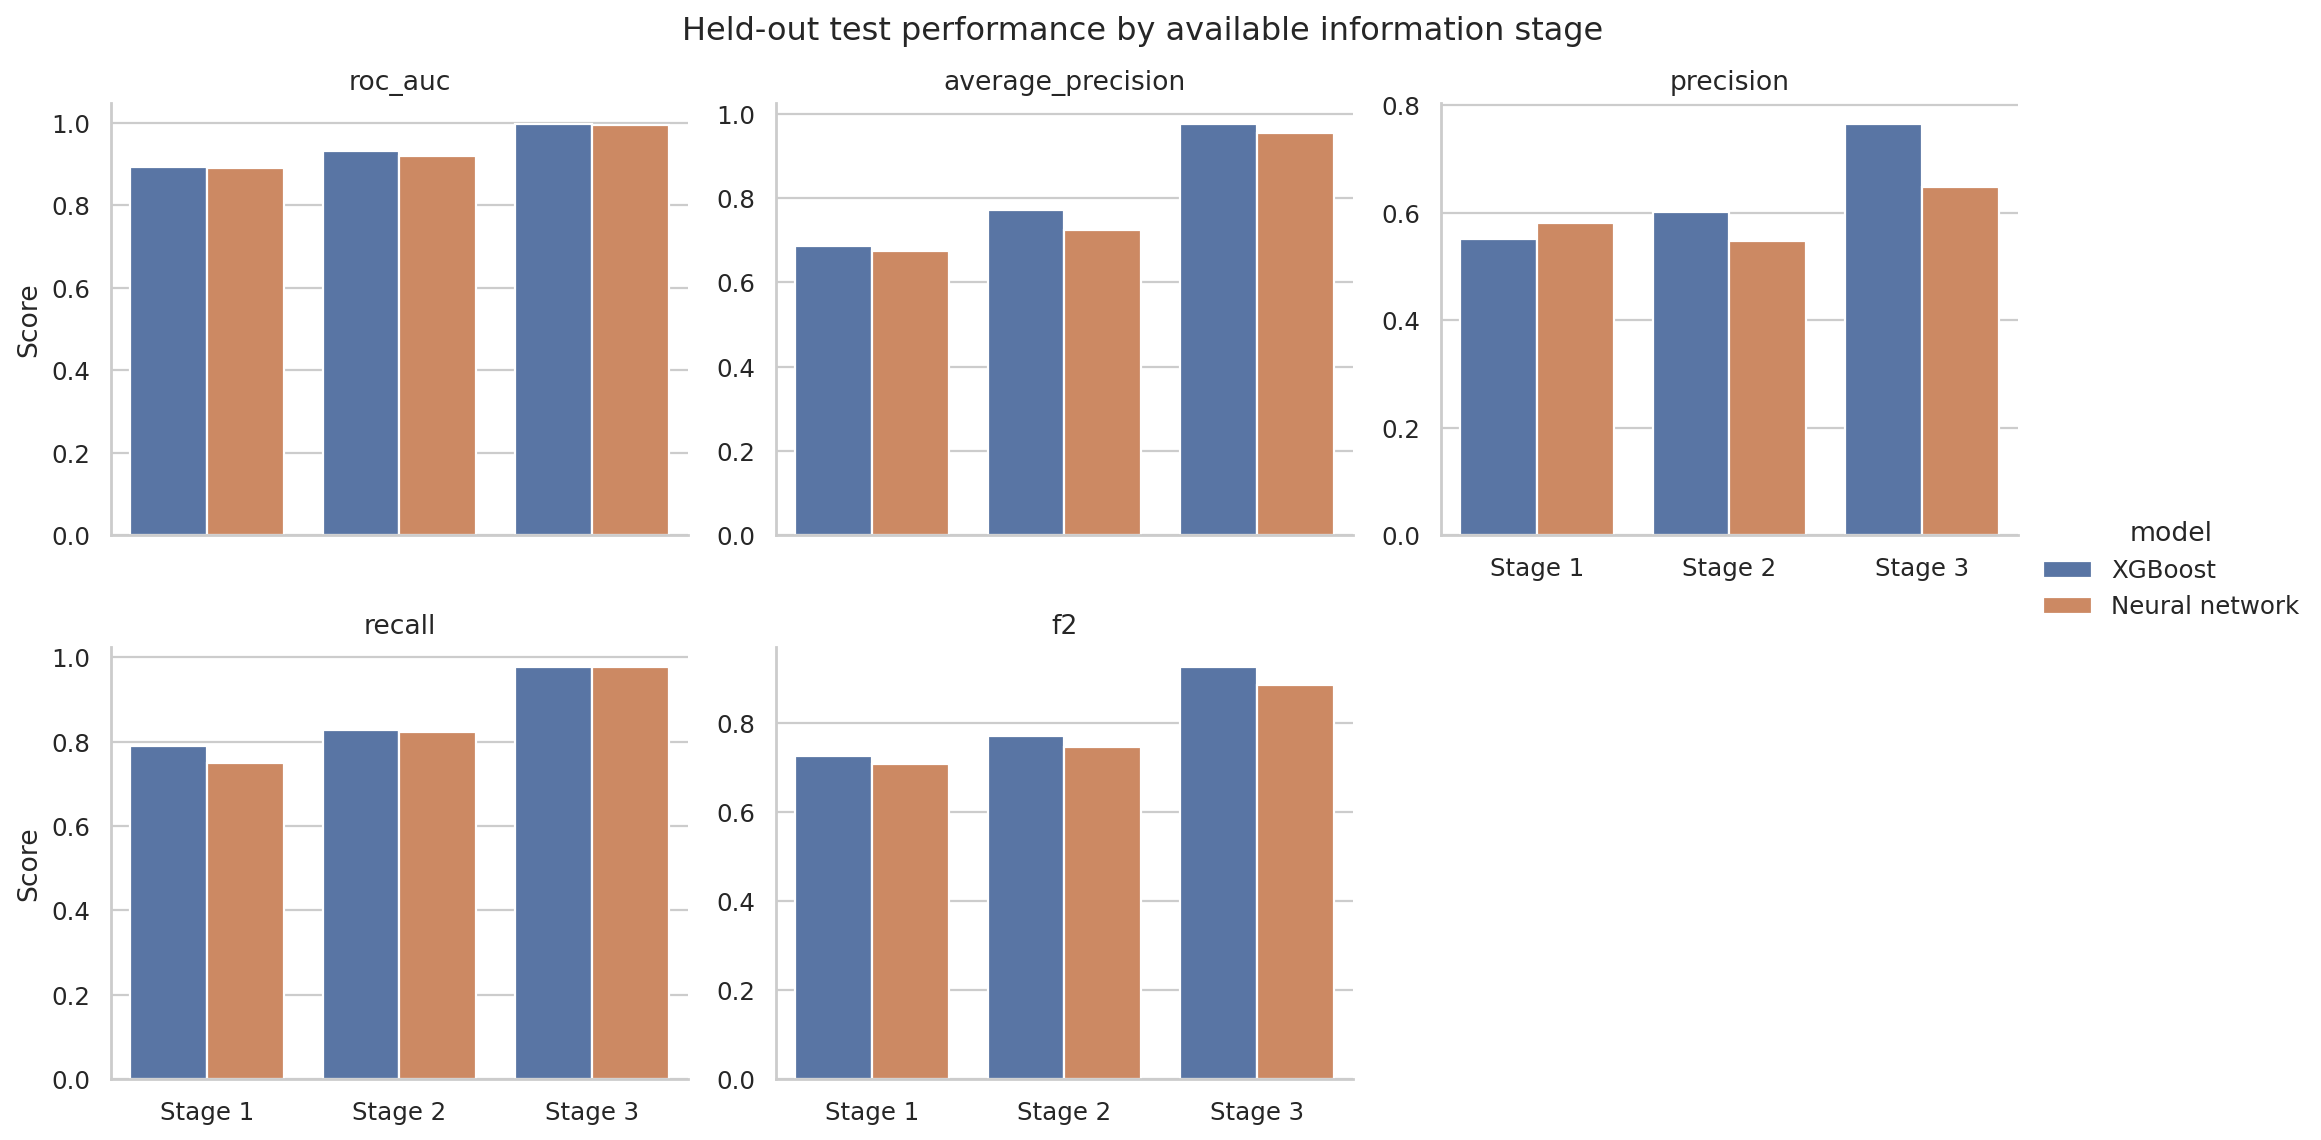

In [6]:
display(Image(filename=PROJECT_ROOT / 'reports/figures/stage_model_comparison.png'))

### Interpretation

Stage 2 produces a credible improvement over intake-only information. XGBoost ROC-AUC rises from 0.893 to 0.930, average precision from 0.686 to 0.771, and recall from 0.790 to 0.828.

Stage 3 must be interpreted differently. All 2,231 records without assessment values are dropouts, so those rows are excluded. The Stage 3 metrics therefore cover 22,828 records (91.1% of the dataset) and describe late-stage classification among learners with assessment data—not early-warning performance.

## Like-for-like Stage 3-eligible cohort

In [7]:
common = outputs["common_cohort"].copy()
for column in ["roc_auc", "average_precision", "precision", "recall", "specificity", "f2", "threshold"]:
    common[column] = common[column].round(3)
display(common)

,stage,model,test_rows,threshold,roc_auc,average_precision,accuracy,precision,recall,specificity,f1,f2,tn,fp,fn,tp
0,Stage 1,Neural network,4552,0.590,0.849,0.412,0.889499,0.325,0.674,0.904,0.437989,0.554,3853,408,95,196
1,Stage 1,XGBoost,4552,0.520,0.854,0.419,0.875879,0.302,0.718,0.887,0.425229,0.563,3778,483,82,209
2,Stage 2,Neural network,4552,0.555,0.897,0.493,0.873023,0.304,0.766,0.880,0.435547,0.588,3751,510,68,223
3,Stage 2,XGBoost,4552,0.520,0.902,0.551,0.893893,0.348,0.756,0.903,0.476706,0.612,3849,412,71,220
4,Stage 3,Neural network,4552,0.195,0.996,0.955,0.964411,0.647,0.976,0.964,0.778082,0.886,4106,155,7,284
5,Stage 3,XGBoost,4552,0.230,0.998,0.977,0.979350,0.765,0.976,0.980,0.858006,0.925,4174,87,7,284


On the same 4,552 Stage 3-eligible test rows, XGBoost ROC-AUC progresses from 0.854 at Stage 1 to 0.902 at Stage 2 and 0.998 at Stage 3. The Stage 3 increase is real within this dataset, but assessment passes and failures occur late and their exact timing relative to dropout is not supplied.

## Errors at the selected operating thresholds

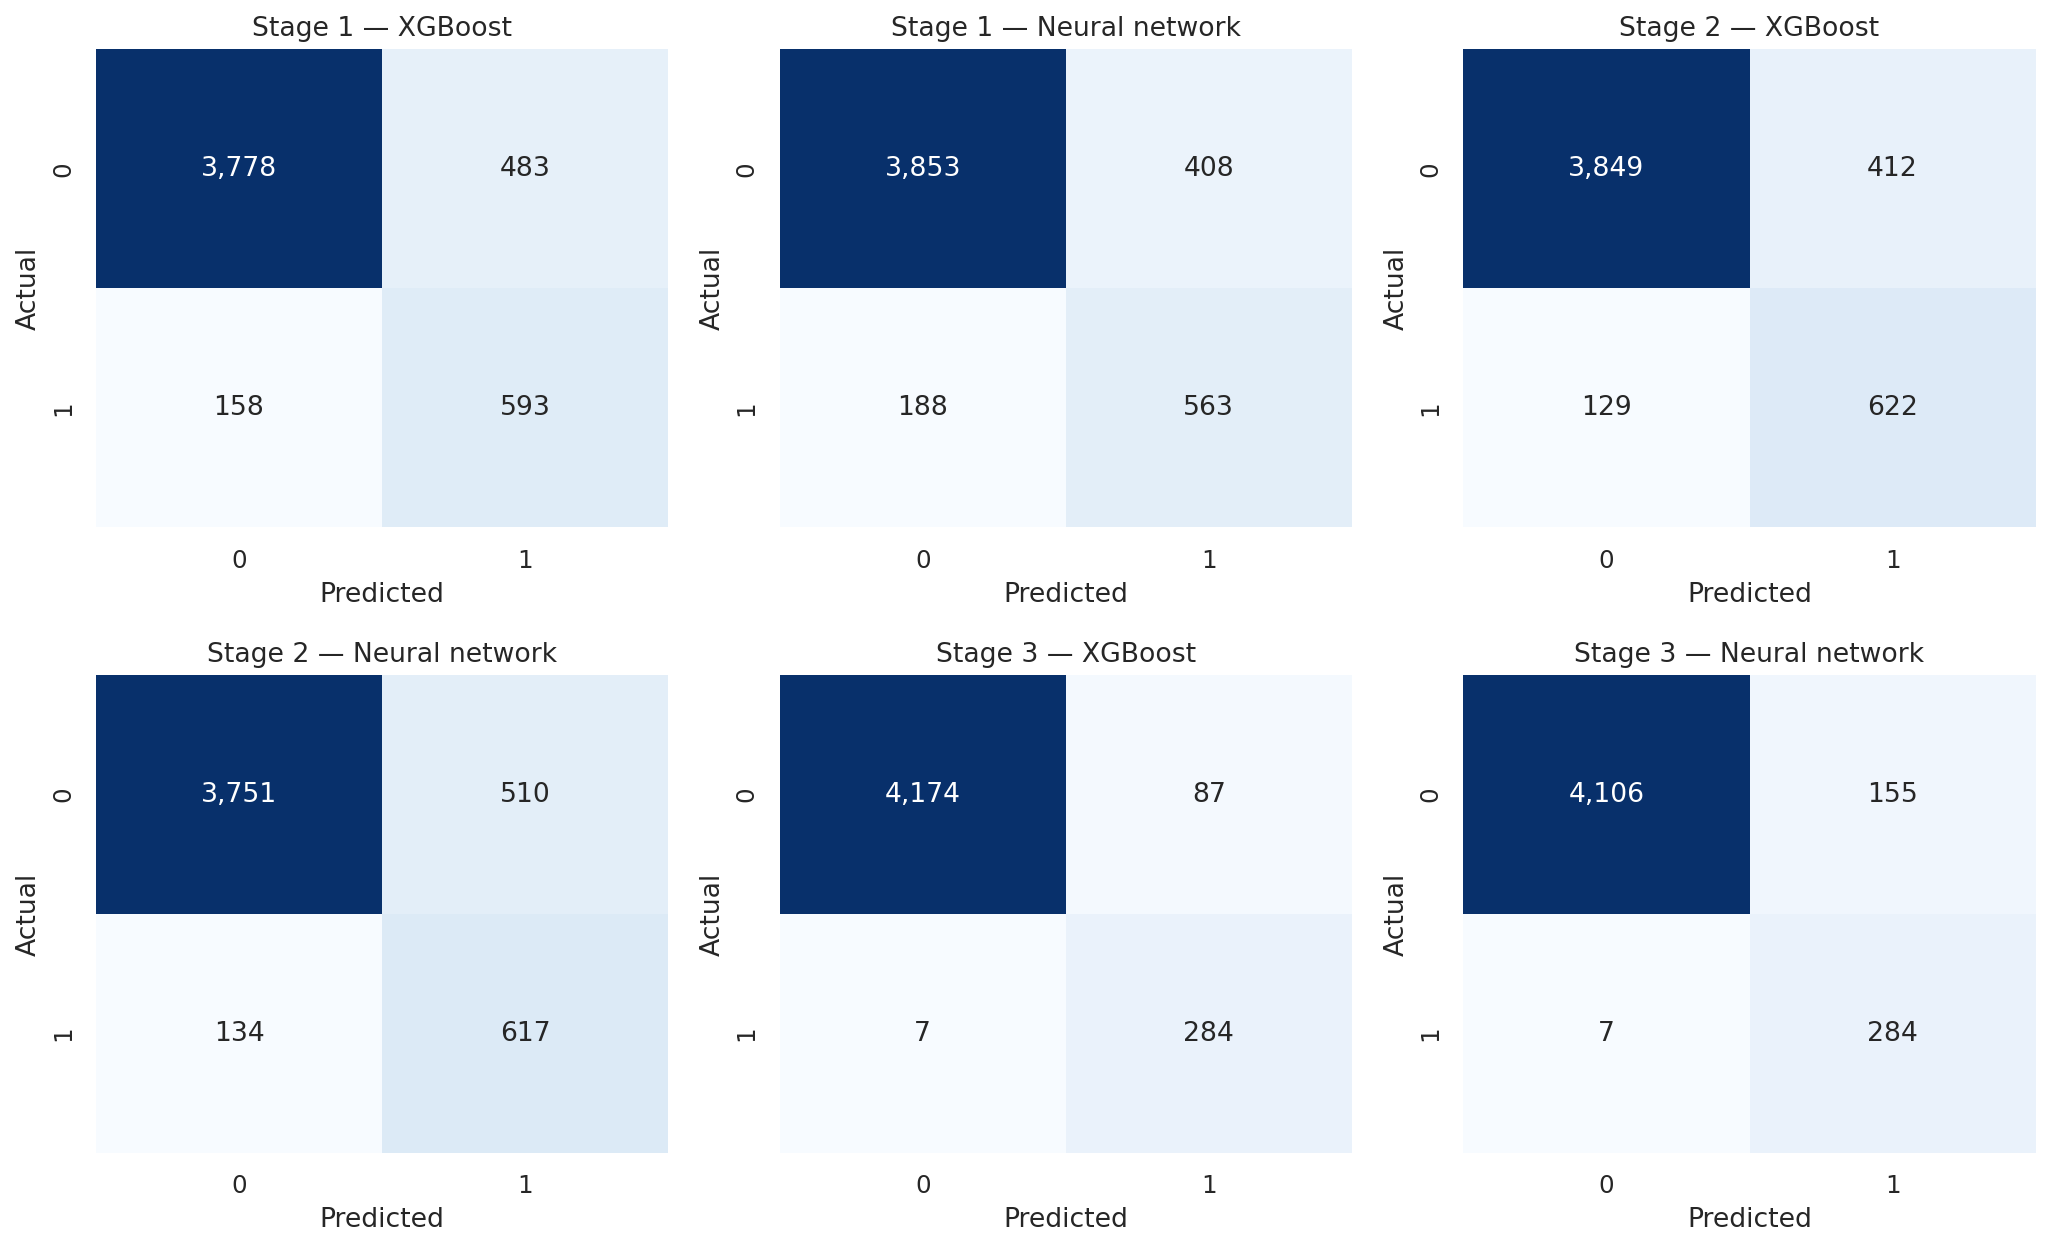

In [8]:
display(Image(filename=PROJECT_ROOT / 'reports/figures/confusion_matrices.png'))

The thresholds deliberately favour recall. This is appropriate for screening, where a false negative may represent a missed intervention, but it increases false positives and therefore staff workload. A real implementation would choose the threshold using intervention capacity, costs and prospective outcomes.

## Stage 3 XGBoost feature importance

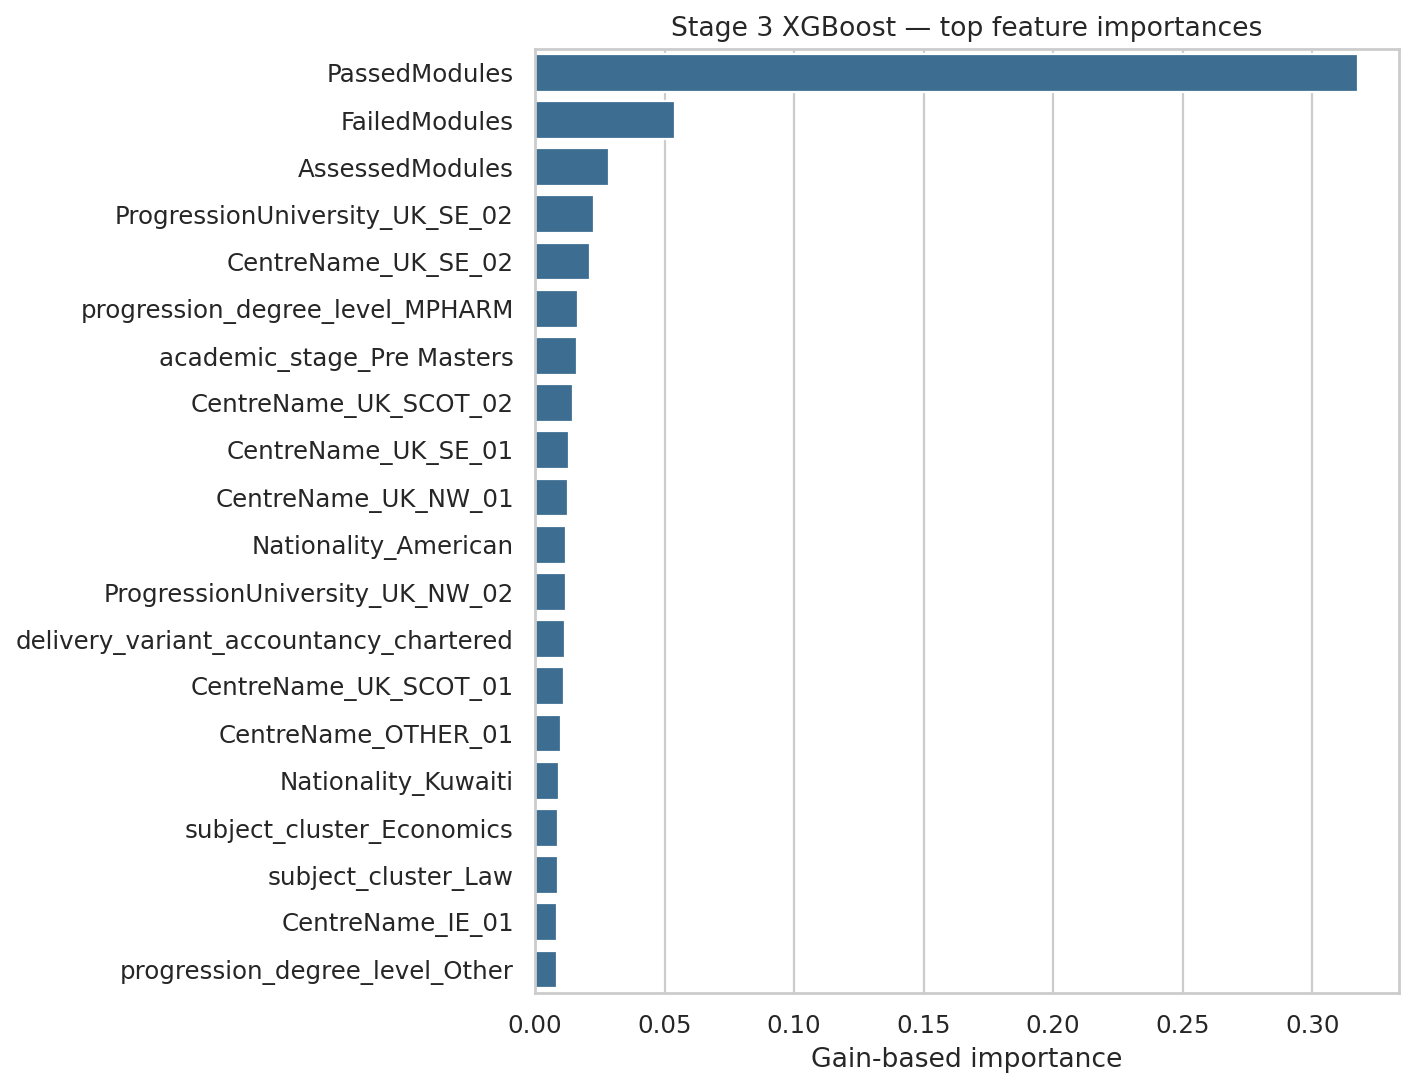

In [9]:
display(Image(filename=PROJECT_ROOT / 'reports/figures/stage_3_xgboost_feature_importance.png'))

Passed and failed module counts dominate Stage 3. Feature importance is predictive, not causal: it does not establish why students leave or show that changing a feature would change an outcome.

## Conclusions and limitations

1. Intake data supports useful early ranking, although performance leaves room for missed learners and false alerts.
2. Attendance adds meaningful predictive signal and is the strongest candidate for an operational early-intervention model in this dataset.
3. Assessment results are highly discriminative but arrive late and exclude many learners who have already left.
4. XGBoost outperforms the neural network at each stage, which is consistent with the strengths of boosted trees on structured tabular data.
5. No dates are supplied, so feature availability relative to dropout cannot be proven. Prospective validation would require explicit prediction cut-offs.
6. Fairness by nationality, gender and centre, probability calibration and intervention-effect evaluation remain future work.

This is an exploratory academic project, not a deployed student-intervention system.